LOADING EV MASTER DATASET
Shape: (1905, 36)

Columns:
['month', 'state_name', 'ev_registrations', '2w_registrations', '3w_registrations', '4w_registrations', 'goods_registrations', 'other_registrations', 'bus_registrations', 'maker_bajaj_auto_ltd', 'maker_hero_motocorp_ltd', 'maker_honda_motorcycle_and_scooter_india_p_ltd', 'maker_hyundai_motor_india_ltd', 'maker_india_yamaha_motor_pvt_ltd', 'maker_mahindra_mahindra_limited', 'maker_maruti_suzuki_india_ltd', 'maker_royal_enfield_unit_of_eicher_ltd', 'maker_suzuki_motorcycle_india_pvt_ltd', 'maker_tvs_motor_company_ltd', 'category_total', '2w_share', '3w_share', '4w_share', 'ev_growth', 'ev_growth_3m', 'ev_growth_12m', 'ev_lag_1', 'ev_lag_3', 'ev_lag_6', 'ev_lag_12', 'ev_rolling_3', 'ev_rolling_6', 'ev_rolling_12', 'year', 'month_number', 'quarter']

Date range:
2019-01-01 00:00:00 to 2024-05-01 00:00:00
States: 34

Features selected:
 - year
 - month_number
 - quarter
 - 2w_registrations
 - 3w_registrations
 - 4w_registrations
 - bus_r

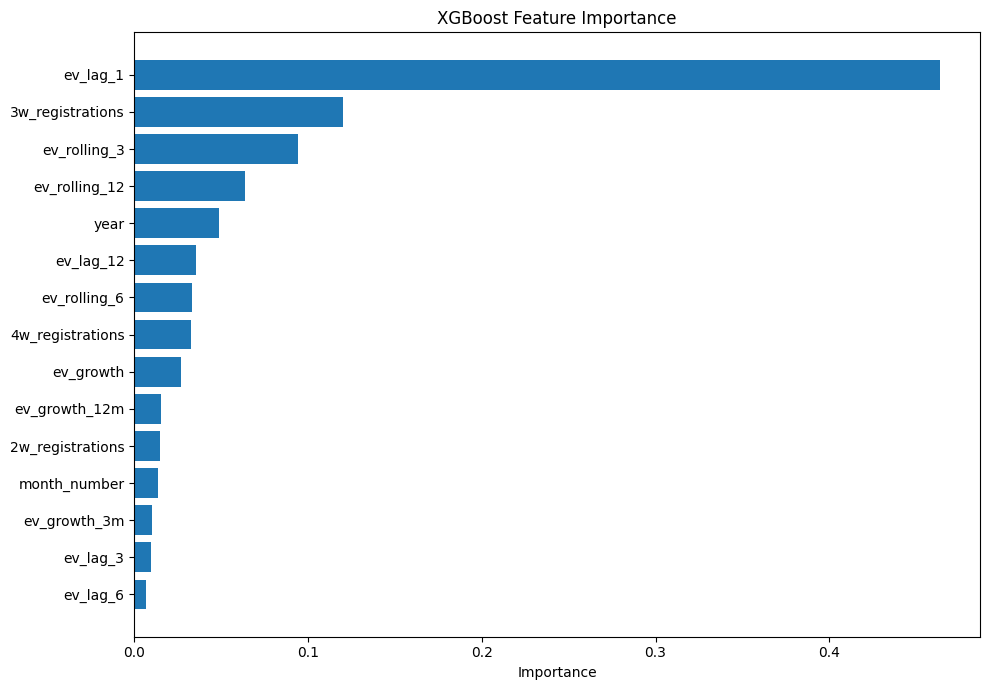

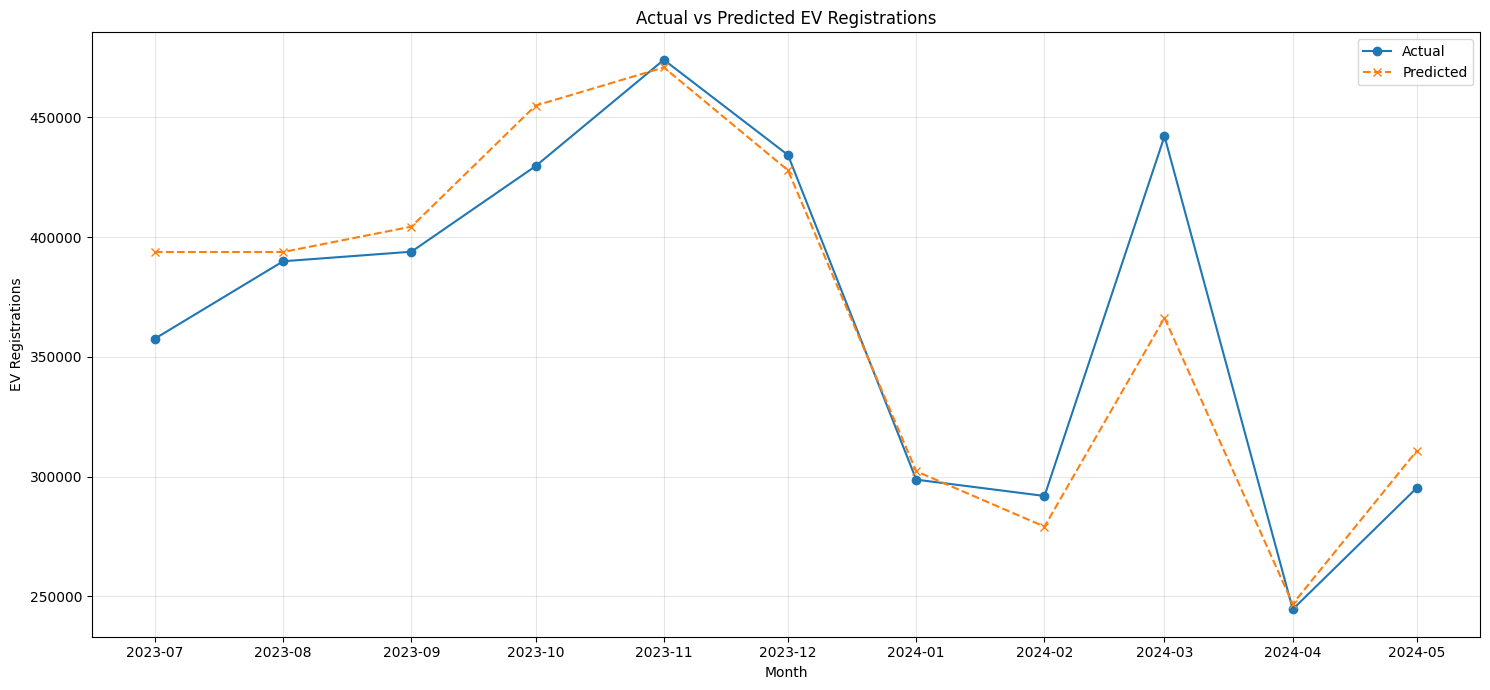


GENERATING 36-MONTH FORECAST

FORECAST CREATED
File: outputs/future_ev_demand_forecast.csv
Rows: 1188

First 20 predictions:
     month                  state_name  forecast_ev
2024-06-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2024-07-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2024-08-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2024-09-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2024-10-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2024-11-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2024-12-01 ANDAMAN AND NICOBAR ISLANDS     7.883698
2025-01-01 ANDAMAN AND NICOBAR ISLANDS    62.151783
2025-02-01 ANDAMAN AND NICOBAR ISLANDS   164.969681
2025-03-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2025-04-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2025-05-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2025-06-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2025-07-01 ANDAMAN AND NICOBAR ISLANDS    58.320660
2025-08-01 ANDAMAN AND NICOBAR ISLANDS     0.000000
2025-09-01 ANDAMAN AND NICOBAR ISLANDS    

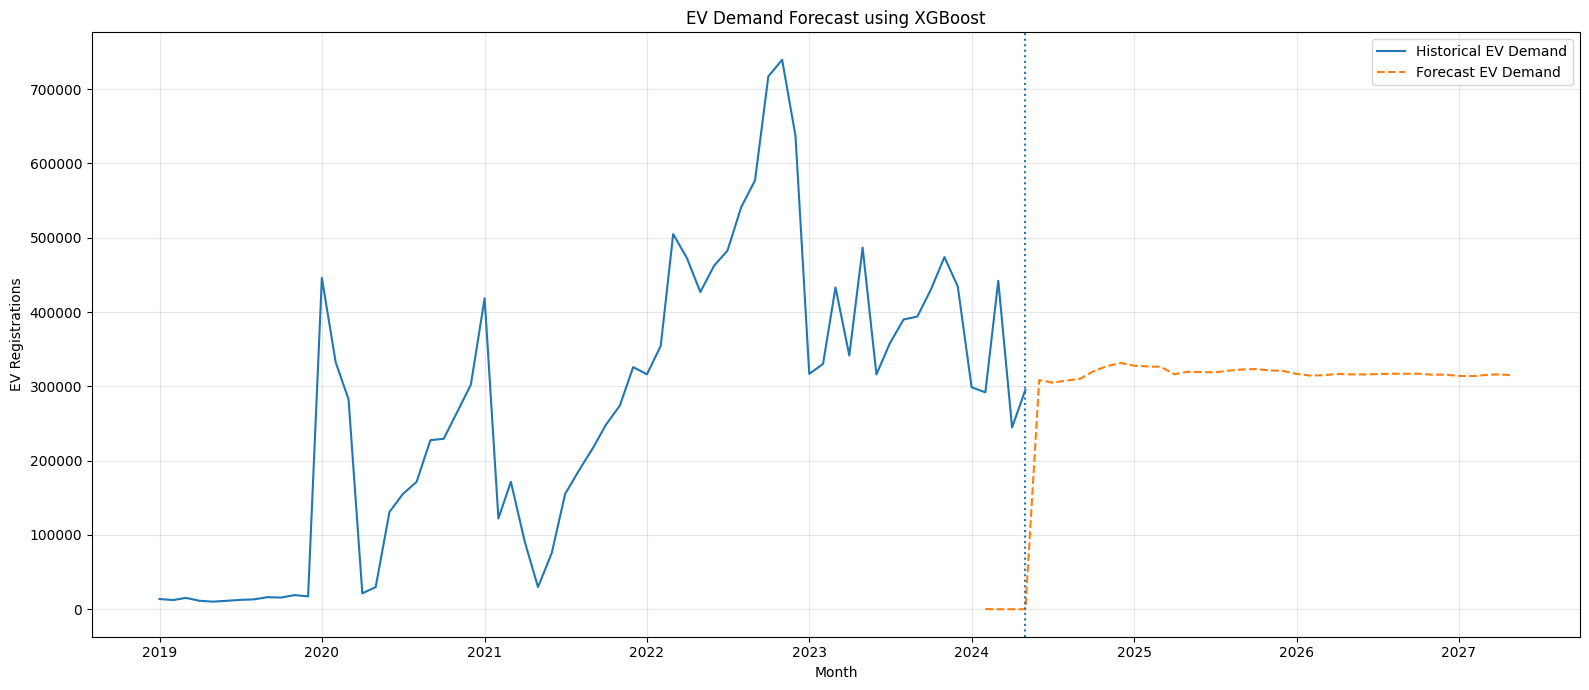


FORECAST SUMMARY
Latest actual EV registrations: 295,388
12-month forecast: 327,773
36-month forecast: 314,892

Generated files:
✓ outputs/future_ev_demand_forecast.csv
✓ outputs/future_ev_demand_forecast.png
✓ outputs/ev_test_predictions.csv
✓ outputs/ev_feature_importance.csv
✓ models/ev_demand_xgboost.pkl

DONE.


In [1]:
# ============================================================
# EV DEMAND FORECASTING
# EV MASTER DATASET -> XGBOOST -> FUTURE EV FORECAST
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# ============================================================
# CONFIG
# ============================================================

DATA_FILE = "/content/ev_master_dataset.csv"

OUTPUT_DIR = "outputs"
MODEL_DIR = "models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

FORECAST_MONTHS = 36


# ============================================================
# 1. LOAD DATA
# ============================================================

print("=" * 70)
print("LOADING EV MASTER DATASET")
print("=" * 70)

df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. CLEAN DATA
# ============================================================

df["month"] = pd.to_datetime(
    df["month"],
    errors="coerce"
)

df["ev_registrations"] = pd.to_numeric(
    df["ev_registrations"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "month",
        "ev_registrations"
    ]
)

df["state_name"] = (
    df["state_name"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df = df.sort_values(
    ["state_name", "month"]
).reset_index(drop=True)


print("\nDate range:")

print(
    df["month"].min(),
    "to",
    df["month"].max()
)

print(
    "States:",
    df["state_name"].nunique()
)


# ============================================================
# 3. CREATE TIME FEATURES
# ============================================================

df["year"] = df["month"].dt.year

df["month_number"] = df["month"].dt.month

df["quarter"] = df["month"].dt.quarter


# ============================================================
# 4. CREATE LAG FEATURES
# ============================================================

# Create again to make the script independent
# of how the master dataset was generated.

df["ev_lag_1"] = (
    df.groupby("state_name")["ev_registrations"]
    .shift(1)
)

df["ev_lag_3"] = (
    df.groupby("state_name")["ev_registrations"]
    .shift(3)
)

df["ev_lag_6"] = (
    df.groupby("state_name")["ev_registrations"]
    .shift(6)
)

df["ev_lag_12"] = (
    df.groupby("state_name")["ev_registrations"]
    .shift(12)
)


# ============================================================
# 5. ROLLING FEATURES
# ============================================================

df["ev_rolling_3"] = (
    df.groupby("state_name")["ev_registrations"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(3)
        .mean()
    )
)

df["ev_rolling_6"] = (
    df.groupby("state_name")["ev_registrations"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(6)
        .mean()
    )
)

df["ev_rolling_12"] = (
    df.groupby("state_name")["ev_registrations"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(12)
        .mean()
    )
)


# ============================================================
# 6. GROWTH FEATURES
# ============================================================

df["ev_growth"] = (
    df.groupby("state_name")["ev_registrations"]
    .pct_change()
    * 100
)

df["ev_growth_3m"] = (
    df.groupby("state_name")["ev_registrations"]
    .pct_change(3)
    * 100
)

df["ev_growth_12m"] = (
    df.groupby("state_name")["ev_registrations"]
    .pct_change(12)
    * 100
)


# ============================================================
# 7. SELECT FEATURES
# ============================================================

candidate_features = [

    "year",
    "month_number",
    "quarter",

    "2w_registrations",
    "3w_registrations",
    "4w_registrations",
    "bus_registrations",

    "2w_share",
    "3w_share",
    "4w_share",

    "ev_growth",
    "ev_growth_3m",
    "ev_growth_12m",

    "ev_lag_1",
    "ev_lag_3",
    "ev_lag_6",
    "ev_lag_12",

    "ev_rolling_3",
    "ev_rolling_6",
    "ev_rolling_12"
]


features = [
    col
    for col in candidate_features
    if col in df.columns
]


print("\nFeatures selected:")

for col in features:
    print(" -", col)


# ============================================================
# 8. REMOVE ROWS WITHOUT ENOUGH HISTORY
# ============================================================

df_model = df.dropna(
    subset=[
        "ev_lag_12",
        "ev_rolling_12"
    ]
).copy()


print(
    "\nRows available for training:",
    len(df_model)
)


# ============================================================
# 9. TIME-BASED TRAIN TEST SPLIT
# ============================================================

unique_dates = sorted(
    df_model["month"].unique()
)

split_index = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[
    split_index
]


train = df_model[
    df_model["month"] < split_date
].copy()

test = df_model[
    df_model["month"] >= split_date
].copy()


print("\n" + "=" * 70)
print("TRAIN / TEST")
print("=" * 70)

print(
    "Train:",
    train["month"].min(),
    "to",
    train["month"].max()
)

print(
    "Test:",
    test["month"].min(),
    "to",
    test["month"].max()
)

print(
    "Train rows:",
    len(train)
)

print(
    "Test rows:",
    len(test)
)


# ============================================================
# 10. X AND Y
# ============================================================

X_train = train[features].copy()

y_train = train["ev_registrations"].copy()

X_test = test[features].copy()

y_test = test["ev_registrations"].copy()


# ============================================================
# 11. HANDLE MISSING VALUES
# ============================================================

medians = X_train.median(
    numeric_only=True
)

X_train = X_train.fillna(
    medians
)

X_test = X_test.fillna(
    medians
)


# ============================================================
# 12. TRAIN XGBOOST
# ============================================================

print("\n" + "=" * 70)
print("TRAINING XGBOOST")
print("=" * 70)


model = XGBRegressor(

    n_estimators=700,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=3,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=1,

    objective="reg:squarederror",

    eval_metric="rmse",

    random_state=42,

    n_jobs=-1

)


model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_test, y_test)
    ],

    verbose=False
)


print(
    "XGBoost training completed."
)


# ============================================================
# 13. TEST PREDICTION
# ============================================================

pred = model.predict(
    X_test
)

pred = np.maximum(
    pred,
    0
)


# ============================================================
# 14. EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

non_zero = y_test != 0

if non_zero.any():

    mape = (
        np.mean(
            np.abs(
                (
                    y_test[non_zero]
                    -
                    pred[non_zero]
                )
                /
                y_test[non_zero]
            )
        )
        * 100
    )

else:

    mape = np.nan


print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(
    f"MAE  : {mae:,.2f}"
)

print(
    f"RMSE : {rmse:,.2f}"
)

print(
    f"R²   : {r2:.4f}"
)

print(
    f"MAPE : {mape:.2f}%"
)


# ============================================================
# 15. SAVE TEST PREDICTIONS
# ============================================================

test_predictions = test[
    [
        "month",
        "state_name",
        "ev_registrations"
    ]
].copy()

test_predictions["predicted_ev"] = pred

test_predictions["absolute_error"] = np.abs(
    test_predictions["ev_registrations"]
    -
    test_predictions["predicted_ev"]
)

test_predictions.to_csv(
    f"{OUTPUT_DIR}/ev_test_predictions.csv",
    index=False
)


# ============================================================
# 16. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "feature":
        features,

    "importance":
        model.feature_importances_

})

importance = importance.sort_values(
    "importance",
    ascending=False
)


print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

print(
    importance.to_string(
        index=False
    )
)


importance.to_csv(
    f"{OUTPUT_DIR}/ev_feature_importance.csv",
    index=False
)


# ============================================================
# 17. FEATURE IMPORTANCE GRAPH
# ============================================================

top_features = importance.head(15)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ev_feature_importance.png",
    dpi=300
)

plt.show()


# ============================================================
# 18. ACTUAL VS PREDICTED
# ============================================================

comparison = (
    test_predictions
    .groupby("month")
    [
        [
            "ev_registrations",
            "predicted_ev"
        ]
    ]
    .sum()
    .reset_index()
)


plt.figure(
    figsize=(15, 7)
)

plt.plot(
    comparison["month"],
    comparison["ev_registrations"],
    marker="o",
    label="Actual"
)

plt.plot(
    comparison["month"],
    comparison["predicted_ev"],
    marker="x",
    linestyle="--",
    label="Predicted"
)

plt.title(
    "Actual vs Predicted EV Registrations"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "EV Registrations"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/actual_vs_predicted_ev.png",
    dpi=300
)

plt.show()


# ============================================================
# 19. SAVE MODEL
# ============================================================

joblib.dump(
    model,
    f"{MODEL_DIR}/ev_demand_xgboost.pkl"
)

joblib.dump(
    features,
    f"{MODEL_DIR}/ev_features.pkl"
)

joblib.dump(
    medians,
    f"{MODEL_DIR}/ev_feature_medians.pkl"
)


# ============================================================
# 20. FUTURE FORECAST
# ============================================================

print("\n" + "=" * 70)
print("GENERATING 36-MONTH FORECAST")
print("=" * 70)


forecast_list = []


for state in df["state_name"].unique():

    state_df = (
        df[
            df["state_name"] == state
        ]
        .sort_values("month")
        .copy()
    )

    # Need at least 12 months
    if len(state_df) < 12:
        continue


    # --------------------------------------------------------
    # EV history
    # --------------------------------------------------------

    history = (
        state_df[
            [
                "month",
                "ev_registrations"
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Category values
    # --------------------------------------------------------

    category_columns = [
        "2w_registrations",
        "3w_registrations",
        "4w_registrations",
        "bus_registrations"
    ]

    available_category_columns = [
        c
        for c in category_columns
        if c in state_df.columns
    ]


    latest_category = (
        state_df.iloc[-1]
    )


    # --------------------------------------------------------
    # Future dates
    # --------------------------------------------------------

    last_date = (
        history["month"].max()
    )

    future_dates = pd.date_range(
        start=last_date + pd.offsets.MonthBegin(1),
        periods=FORECAST_MONTHS,
        freq="MS"
    )


    # ========================================================
    # RECURSIVE FORECAST
    # ========================================================

    for future_date in future_dates:

        values = (
            history["ev_registrations"]
            .tolist()
        )


        # Need enough history
        if len(values) < 12:
            break


        # ----------------------------------------------------
        # LAGS
        # ----------------------------------------------------

        lag_1 = values[-1]

        lag_3 = values[-3]

        lag_6 = values[-6]

        lag_12 = values[-12]


        # ----------------------------------------------------
        # ROLLING
        # ----------------------------------------------------

        rolling_3 = np.mean(
            values[-3:]
        )

        rolling_6 = np.mean(
            values[-6:]
        )

        rolling_12 = np.mean(
            values[-12:]
        )


        # ----------------------------------------------------
        # GROWTH
        # ----------------------------------------------------

        growth = (
            (
                values[-1]
                -
                values[-2]
            )
            /
            max(
                abs(values[-2]),
                1
            )
            * 100
        )


        growth_3m = (
            (
                values[-1]
                -
                values[-4]
            )
            /
            max(
                abs(values[-4]),
                1
            )
            * 100
        )


        growth_12m = (
            (
                values[-1]
                -
                values[-13]
            )
            /
            max(
                abs(values[-13]),
                1
            )
            * 100
        ) if len(values) >= 13 else 0


        # ----------------------------------------------------
        # CATEGORY FEATURES
        # ----------------------------------------------------

        row = {

            "year":
                future_date.year,

            "month_number":
                future_date.month,

            "quarter":
                future_date.quarter,

            "ev_lag_1":
                lag_1,

            "ev_lag_3":
                lag_3,

            "ev_lag_6":
                lag_6,

            "ev_lag_12":
                lag_12,

            "ev_rolling_3":
                rolling_3,

            "ev_rolling_6":
                rolling_6,

            "ev_rolling_12":
                rolling_12,

            "ev_growth":
                growth,

            "ev_growth_3m":
                growth_3m,

            "ev_growth_12m":
                growth_12m
        }


        # Add latest category values
        for col in [
            "2w_registrations",
            "3w_registrations",
            "4w_registrations",
            "bus_registrations",
            "2w_share",
            "3w_share",
            "4w_share"
        ]:

            if col in features:

                if col in latest_category:

                    row[col] = (
                        latest_category[col]
                    )

                else:

                    row[col] = 0


        # ----------------------------------------------------
        # Missing feature columns
        # ----------------------------------------------------

        for feature in features:

            if feature not in row:

                row[feature] = 0


        future_X = pd.DataFrame(
            [row]
        )

        future_X = future_X[
            features
        ]


        future_X = future_X.fillna(
            medians
        )


        # ----------------------------------------------------
        # PREDICT
        # ----------------------------------------------------

        forecast = model.predict(
            future_X
        )[0]


        forecast = max(
            0,
            forecast
        )


        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        forecast_list.append({

            "month":
                future_date,

            "state_name":
                state,

            "forecast_ev":
                forecast

        })


        # ----------------------------------------------------
        # ADD PREDICTION TO HISTORY
        # ----------------------------------------------------

        history.loc[
            len(history)
        ] = [
            future_date,
            forecast
        ]


# ============================================================
# 21. FORECAST DATAFRAME
# ============================================================

forecast_df = pd.DataFrame(
    forecast_list
)


if forecast_df.empty:

    raise ValueError(
        "No future forecast generated. "
        "Check your dataset history."
    )


forecast_df = forecast_df.sort_values(
    [
        "state_name",
        "month"
    ]
)


# ============================================================
# 22. SAVE FUTURE FORECAST
# ============================================================

FORECAST_FILE = (
    f"{OUTPUT_DIR}/"
    "future_ev_demand_forecast.csv"
)

forecast_df.to_csv(
    FORECAST_FILE,
    index=False
)


print("\n" + "=" * 70)
print("FORECAST CREATED")
print("=" * 70)

print(
    "File:",
    FORECAST_FILE
)

print(
    "Rows:",
    len(forecast_df)
)


print("\nFirst 20 predictions:")

print(
    forecast_df.head(20).to_string(
        index=False
    )
)


# ============================================================
# 23. OVERALL FORECAST
# ============================================================

overall_forecast = (
    forecast_df
    .groupby("month")["forecast_ev"]
    .sum()
    .reset_index()
)


print("\nOverall forecast:")

print(
    overall_forecast.head(12)
)


# ============================================================
# 24. FORECAST GRAPH
# ============================================================

historical = (
    df
    .groupby("month")["ev_registrations"]
    .sum()
    .reset_index()
)


plt.figure(
    figsize=(16, 7)
)

plt.plot(
    historical["month"],
    historical["ev_registrations"],
    label="Historical EV Demand"
)

plt.plot(
    overall_forecast["month"],
    overall_forecast["forecast_ev"],
    linestyle="--",
    label="Forecast EV Demand"
)

plt.axvline(
    historical["month"].max(),
    linestyle=":"
)

plt.title(
    "EV Demand Forecast using XGBoost"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "EV Registrations"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/future_ev_demand_forecast.png",
    dpi=300
)

plt.show()


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

latest_actual = (
    historical["ev_registrations"]
    .iloc[-1]
)

forecast_12 = (
    overall_forecast["forecast_ev"]
    .iloc[
        min(
            11,
            len(overall_forecast) - 1
        )
    ]
)

forecast_36 = (
    overall_forecast["forecast_ev"]
    .iloc[-1]
)


print("\n" + "=" * 70)
print("FORECAST SUMMARY")
print("=" * 70)

print(
    f"Latest actual EV registrations: "
    f"{latest_actual:,.0f}"
)

print(
    f"12-month forecast: "
    f"{forecast_12:,.0f}"
)

print(
    f"36-month forecast: "
    f"{forecast_36:,.0f}"
)

print("\nGenerated files:")

print(
    "✓ outputs/future_ev_demand_forecast.csv"
)

print(
    "✓ outputs/future_ev_demand_forecast.png"
)

print(
    "✓ outputs/ev_test_predictions.csv"
)

print(
    "✓ outputs/ev_feature_importance.csv"
)

print(
    "✓ models/ev_demand_xgboost.pkl"
)

print("\nDONE.")